In [1]:
import pandas as pd

df = pd.read_csv("./data/datasets/combined_results.csv")

In [2]:
df.head()

,ai_svm,ai_ffnn,ai_distilbert,ai_roberta,y
0,0.101422,0.036870,0.000209,0.000180,0
1,0.825717,0.814764,0.067708,0.000196,0
2,0.001765,0.007352,0.000020,0.000213,0
3,0.102390,0.206996,0.000197,0.000341,0
4,0.101594,0.507764,0.057889,0.000210,0


In [3]:
# Collect data

X = []
y = []

for index, row in df.iterrows():
    X.append([row[0], row[1], row[2], row[3]])
    y.append(row[4])

/tmp/ipykernel_69429/2484173611.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X.append([row[0], row[1], row[2], row[3]])
/tmp/ipykernel_69429/2484173611.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y.append(row[4])


In [4]:
# Split data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11, stratify=y
)

In [5]:
X_train[0]

[np.float64(0.0027515465113961),
 np.float64(0.0083617866039276),
 np.float64(2.3524156858911734e-05),
 np.float64(0.0002039770333794)]

In [6]:
y_train[0]

np.float64(0.0)

In [7]:
# Get classifier
from sklearn.ensemble import GradientBoostingClassifier

classifier = GradientBoostingClassifier()
classifier.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [8]:
# Store classifier

import pickle
with open("./data/gbm", "wb") as f:
    pickle.dump(classifier, f)

In [5]:
# Load classifier
import pickle

with open("./data/gbm", "rb") as f:
    classifier = pickle.load(f)

In [6]:
import numpy as np

def test_boost(cutoff):
    human_as_human = 0
    human_as_ai = 0
    ai_as_ai = 0
    ai_as_human = 0
    
    for i in range(len(X_test)):
        X = [X_test[i]]
        y = y_test[i]
        
        pred = classifier.predict_proba(X)[0][1]
        if y == 0 and pred <= cutoff:
            human_as_human += 1
        elif y == 0 and pred >= cutoff:
            human_as_ai += 1
        elif y == 1 and pred <= cutoff:
            ai_as_human += 1
        else:
            ai_as_ai += 1
            
    cm = np.array([
        [human_as_human, human_as_ai],
        [ai_as_human, ai_as_ai]
    ])
            
    return cm

In [7]:
test_probas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9,
               0.925, 0.95, 0.975, 0.99, 0.995]

In [8]:
received_cms = []
for p in test_probas:
    received_cms.append(test_boost(p))

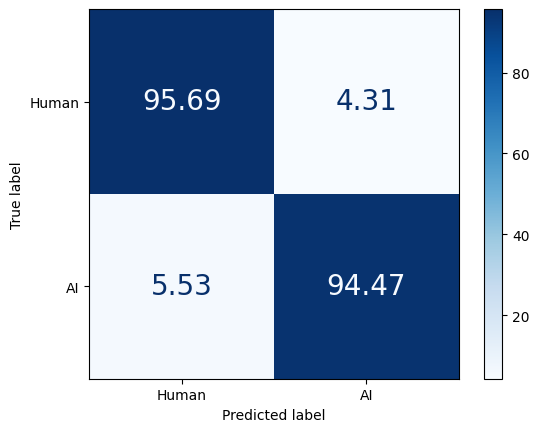

0.5 & 20,100 & 905 & 1,090 & 18,637 & 0.9510 & 0.9537 & 0.9447 & 0.9569 \\


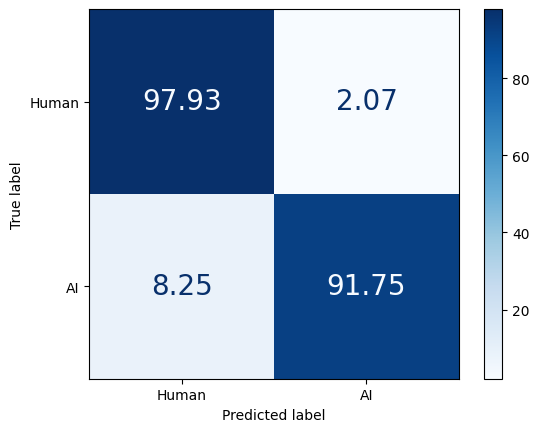

0.6 & 20,571 & 434 & 1,627 & 18,100 & 0.9494 & 0.9766 & 0.9175 & 0.9793 \\


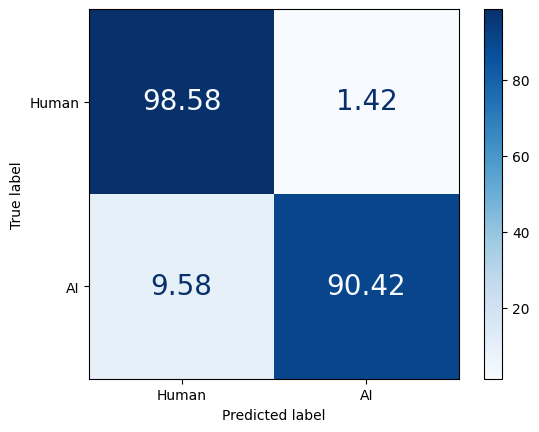

0.7 & 20,707 & 298 & 1,890 & 17,837 & 0.9463 & 0.9836 & 0.9042 & 0.9858 \\


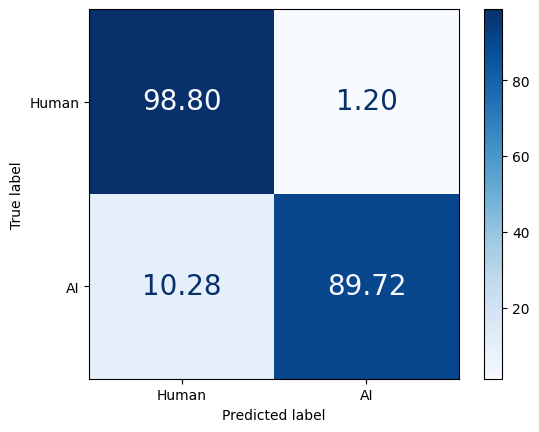

0.75 & 20,753 & 252 & 2,028 & 17,699 & 0.9440 & 0.9860 & 0.8972 & 0.9880 \\


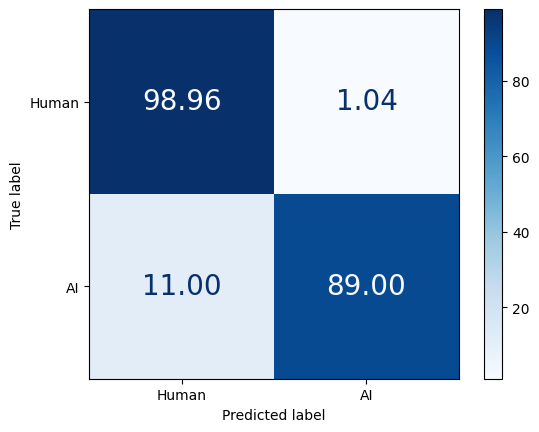

0.8 & 20,786 & 219 & 2,170 & 17,557 & 0.9413 & 0.9877 & 0.8900 & 0.9896 \\


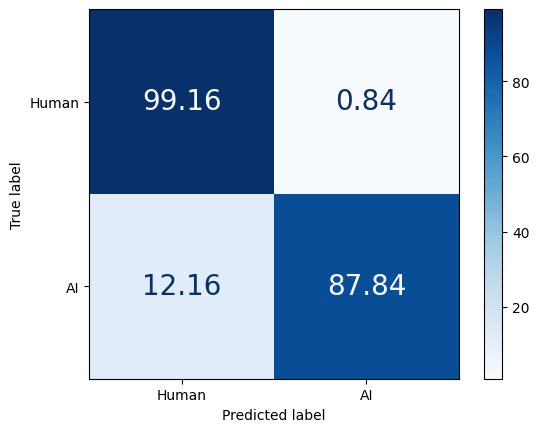

0.85 & 20,828 & 177 & 2,399 & 17,328 & 0.9368 & 0.9899 & 0.8784 & 0.9916 \\


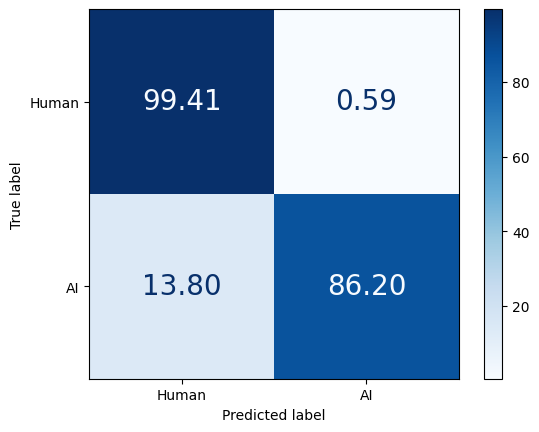

0.9 & 20,882 & 123 & 2,722 & 17,005 & 0.9302 & 0.9928 & 0.8620 & 0.9941 \\


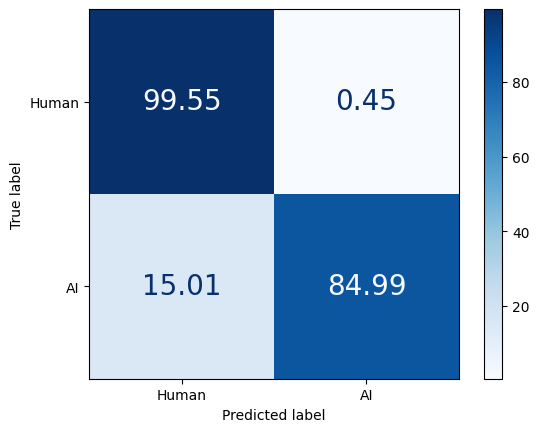

0.925 & 20,911 & 94 & 2,961 & 16,766 & 0.9250 & 0.9944 & 0.8499 & 0.9955 \\


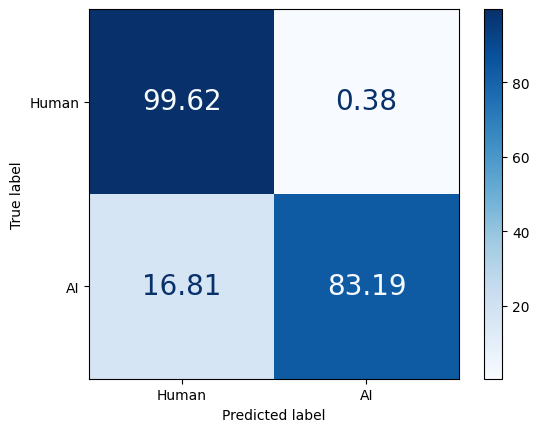

0.95 & 20,926 & 79 & 3,317 & 16,410 & 0.9166 & 0.9952 & 0.8319 & 0.9962 \\


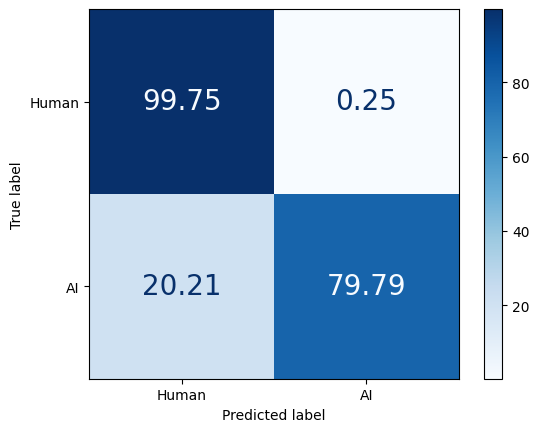

0.975 & 20,952 & 53 & 3,986 & 15,741 & 0.9008 & 0.9966 & 0.7979 & 0.9975 \\


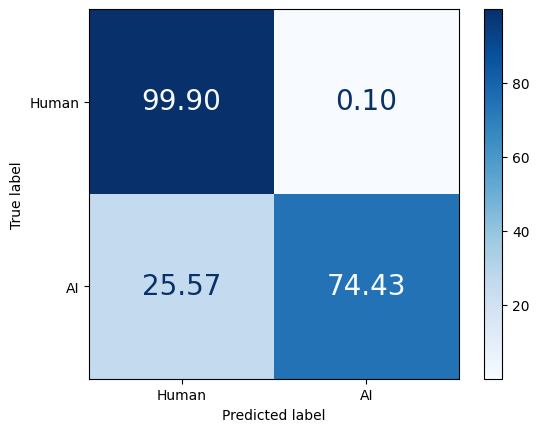

0.99 & 20,983 & 22 & 5,045 & 14,682 & 0.8756 & 0.9985 & 0.7443 & 0.9990 \\


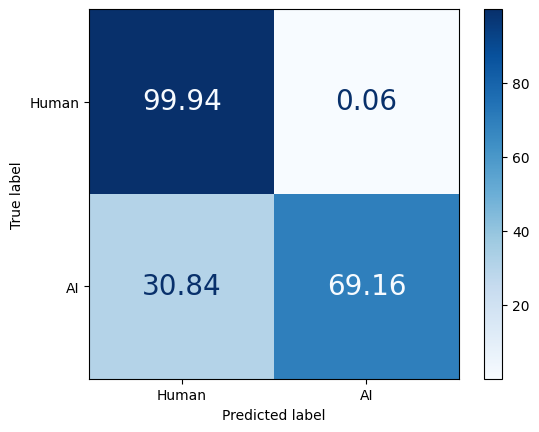

0.995 & 20,993 & 12 & 6,084 & 13,643 & 0.8503 & 0.9991 & 0.6916 & 0.9994 \\


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import *

for i in range(len(received_cms)):
    cm = received_cms[i]
    
    cm_p = cm / cm.sum(axis=1, keepdims=True) * 100
    display = ConfusionMatrixDisplay(
        confusion_matrix = cm_p,
        display_labels = ["Human", "AI"]
    )
    display.plot(cmap="Blues", values_format=".2f")
    for text in display.text_.ravel():
        text.set_fontsize(20)
        
    plt.savefig(f"./data/figures/boosting/{int(test_probas[i]*1000)}.pdf")
    plt.show()
    
    # Scores
    TN, FP, FN, TP = cm.ravel()
    
    """
    cm = np.array([
        [human_as_human, human_as_ai],
        [ai_as_human, ai_as_ai]
    ])
    """
    y_true = [0] * (TN + FP) + [1] * (FN + TP)
    y_pred = [0] * TN + [1] * FP + [0] * FN + [1] * TP
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    specificity = TN / (TN + FP)
    
    print(f"{test_probas[i]} & "
          f"{TN:,.0f} & {FP:,.0f} & {FN:,.0f} & {TP:,.0f} & {accuracy:.4f} & {precision:.4f}"
          f" & {recall:.4f} & {specificity:.4f} \\\\")

In [14]:
len(X_test)

40732

In [15]:
# SHAP explanation
import numpy as np
import shap

X_train = np.array(X_train)
X_test = np.array(X_test)

explainer = shap.Explainer(classifier, X_test, feature_names=["SVM", "FFNN", "DistilBERT", "RoBERTa"])

/home/tobias/.pyenv/versions/genai/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
X_train.shape

(162926, 4)

In [17]:
X_test.shape

(40732, 4)

In [18]:
shap_values = explainer(X_test)

 97%|=================== | 39528/40732 [00:22<00:00]       

In [19]:
import matplotlib.pyplot as plt
shap.initjs()

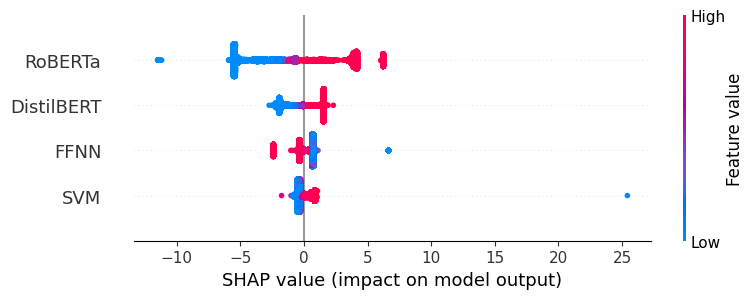

In [20]:
# Plot
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.savefig("./data/figures/shap_dot.pdf")

In [21]:
X_test[0]

array([1.42976935e-02, 9.82784200e-03, 2.62562371e-05, 2.17901907e-04])

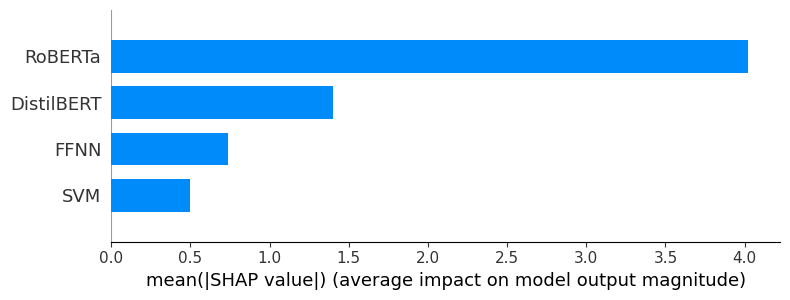

In [22]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.savefig("./data/figures/shap_bar.pdf")

In [23]:
shap.waterfall_plot(shap_values[1], show=False)
plt.savefig("./data/figures/shap_waterfall.pdf")

In [9]:
# Compute data for ROC-AUC

scores = []
for i in range(len(X_test)):
    X = [X_test[i]]        
    pred = classifier.predict_proba(X)[0][1]
    scores.append(pred)   

In [44]:
scores = np.array(scores)

In [45]:
from sklearn.metrics import *
fpr, tpr, thresholds = roc_curve(y_test, scores)

In [46]:
roc_auc_score(y_test, scores)

0.9922304995200676

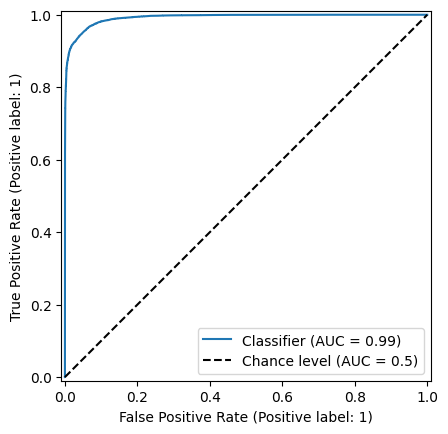

In [50]:
import matplotlib.pylab as plt
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_predictions(y_test, scores, pos_label=1, plot_chance_level=True)

In [52]:
optimum = (tpr-fpr).argmax()

In [55]:
threshold = thresholds[optimum]

In [56]:
threshold

np.float64(0.5042467238602916)